# Exercício 1 - Construção manual da Árvore de Decisão com ID3

In [ ]:
!pip install graphviz


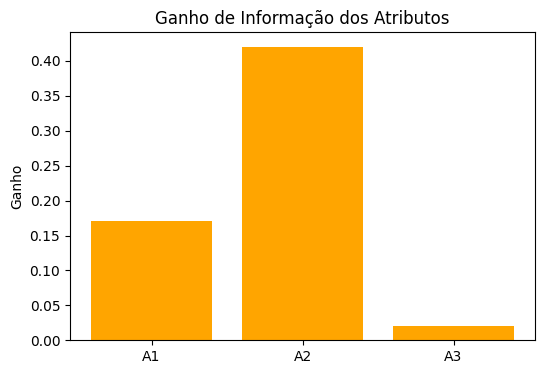

,Atributo,Ganho
0,A1,0.170951
1,A2,0.419973
2,A3,0.019973


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from graphviz import Digraph

# Dados
data = pd.DataFrame({
    'A1': [1, 1, 0, 1, 1],
    'A2': [0, 0, 1, 1, 1],
    'A3': [0, 1, 0, 1, 0],
    'y':  [0, 0, 0, 1, 1]
})

# Entropia
def entropy(subset):
    values, counts = np.unique(subset['y'], return_counts=True)
    probabilities = counts / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities + 1e-9))  # evitar log(0)

# Ganho de informação
def information_gain(data, split_attribute):
    total_entropy = entropy(data)
    values, counts = np.unique(data[split_attribute], return_counts=True)
    weighted_entropy = 0
    for v, c in zip(values, counts):
        subset = data[data[split_attribute] == v]
        weighted_entropy += (c / len(data)) * entropy(subset)
    gain = total_entropy - weighted_entropy
    return gain

# Algoritmo ID3
def id3(data, atributos, dot, parent=None, edge_label=""):
    if len(np.unique(data['y'])) == 1:
        label = f"Classe {np.unique(data['y'])[0]}"
        node_id = str(id(label))
        dot.node(node_id, label, shape="box", style="filled", color="lightblue")
        if parent:
            dot.edge(parent, node_id, label=edge_label)
        return node_id

    if len(atributos) == 0:
        label = f"Classe {data['y'].mode()[0]}"
        node_id = str(id(label))
        dot.node(node_id, label, shape="box", style="filled", color="lightblue")
        if parent:
            dot.edge(parent, node_id, label=edge_label)
        return node_id

    ganhos = [information_gain(data, attr) for attr in atributos]
    melhor_atributo = atributos[np.argmax(ganhos)]
    node_id = str(id(melhor_atributo))
    dot.node(node_id, melhor_atributo, shape="ellipse", style="filled", color="lightgreen")

    if parent:
        dot.edge(parent, node_id, label=edge_label)

    for valor in np.unique(data[melhor_atributo]):
        subset = data[data[melhor_atributo] == valor]
        if subset.empty:
            label = f"Classe {data['y'].mode()[0]}"
            child_id = str(id(label))
            dot.node(child_id, label, shape="box", style="filled", color="lightblue")
            dot.edge(node_id, child_id, label=str(valor))
        else:
            novos_atributos = [a for a in atributos if a != melhor_atributo]
            id3(subset, novos_atributos, dot, parent=node_id, edge_label=str(valor))

    return node_id
# 📊 Gráfico dos ganhos
plt.figure(figsize=(6,4))
plt.bar(gains.keys(), gains.values(), color='orange')
plt.title('Ganho de Informação dos Atributos')
plt.ylabel('Ganho')
plt.show()

# Criar o grafo
dot = Digraph()

# Construir árvore
id3(data, atributos=['A1', 'A2', 'A3'], dot=dot)

# Renderizar
dot.render('arvore_decisao', format='png', cleanup=True)
dot.view('arvore_decisao')

# Mostrar os ganhos
gains_df = pd.DataFrame(list(gains.items()), columns=['Atributo', 'Ganho'])
display(gains_df)


# Exercício 2 - Árvore para função XOR com ID3 manual

In [ ]:

# Tabela XOR
p_pos = 2/4
ent_total = entropy(p_pos)
print(f'Entropia total: {ent_total:.4f}')

# Atributo x1:
rem_x1 = (2/4)*1 + (2/4)*1
gain_x1 = ent_total - rem_x1

# Atributo x2:
rem_x2 = (2/4)*1 + (2/4)*1
gain_x2 = ent_total - rem_x2

print(f"Ganho x1: {gain_x1:.4f}")
print(f"Ganho x2: {gain_x2:.4f}")

# Ambos os atributos têm ganho zero.


Entropia total: 1.0000
Ganho x1: 0.0000
Ganho x2: 0.0000


# Exercício 3 - Decision Tree no dataset Moons

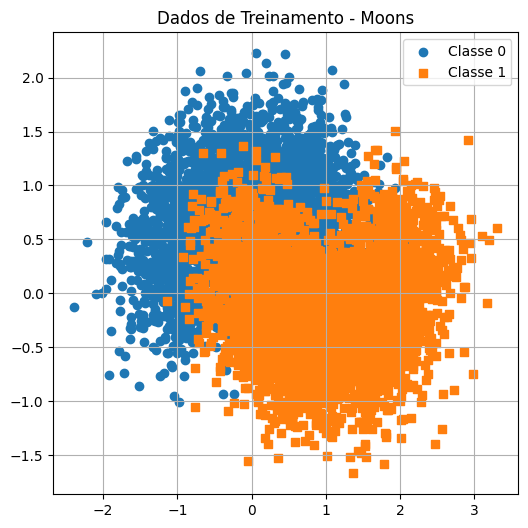

Fitting 5 folds for each of 98 candidates, totalling 490 fits
Melhores parâmetros: {'max_leaf_nodes': 33}
Melhor score: 0.8594666666666665
Acurácia: 0.8632


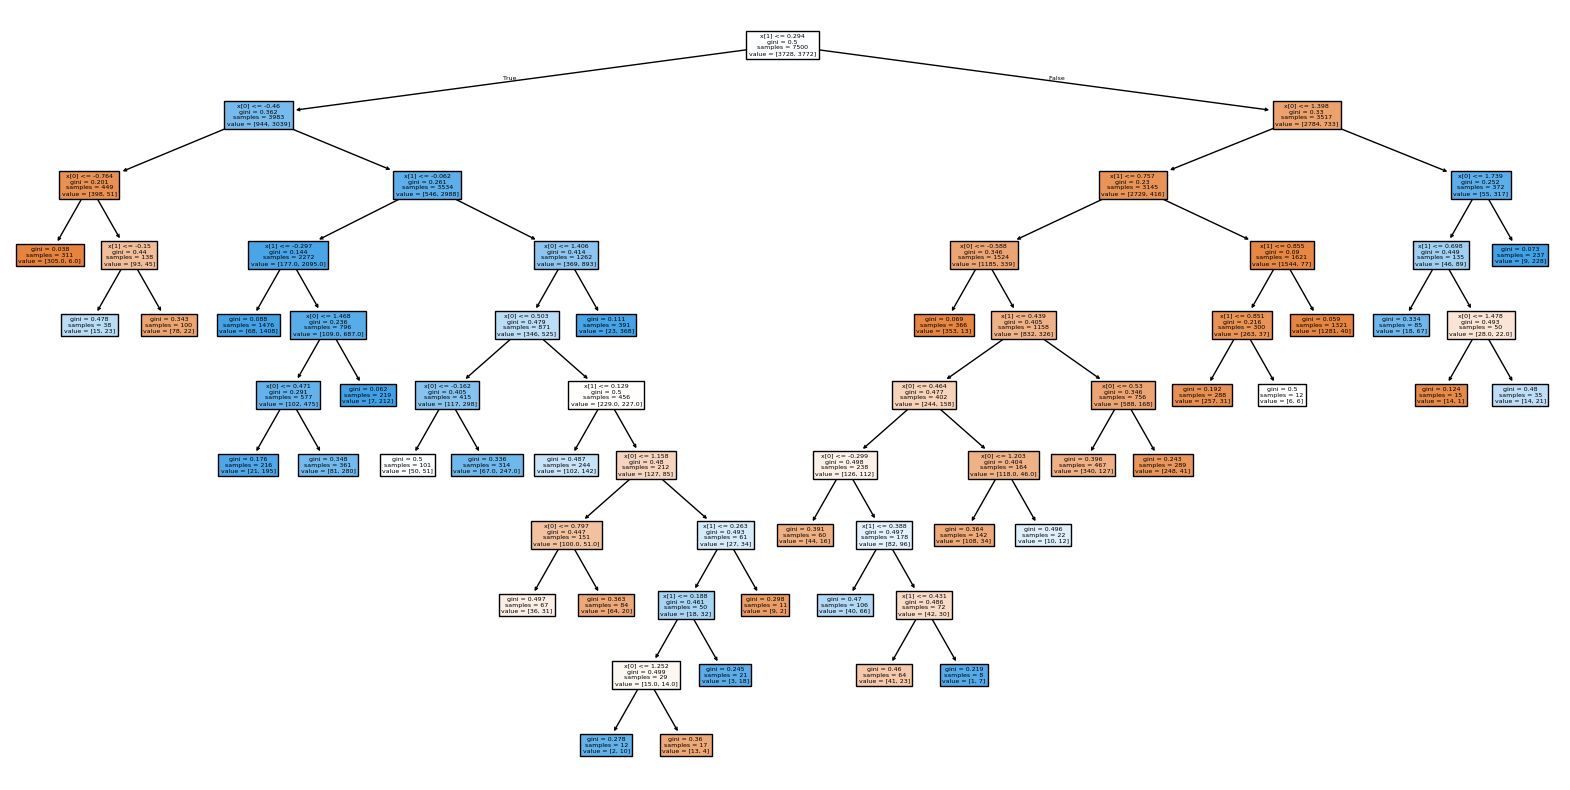

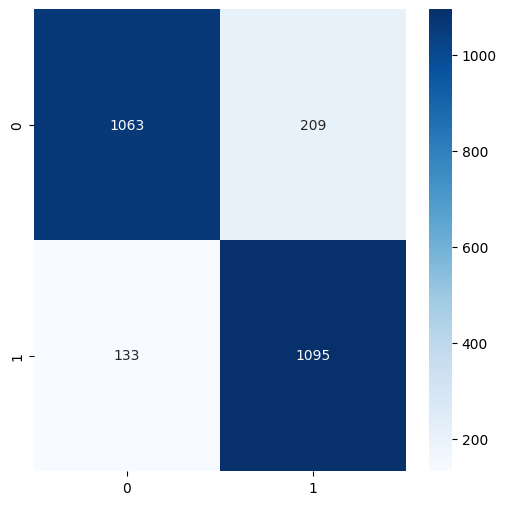

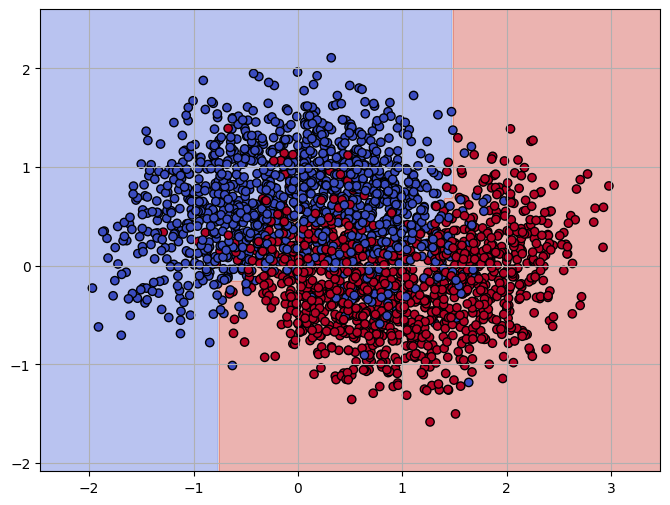

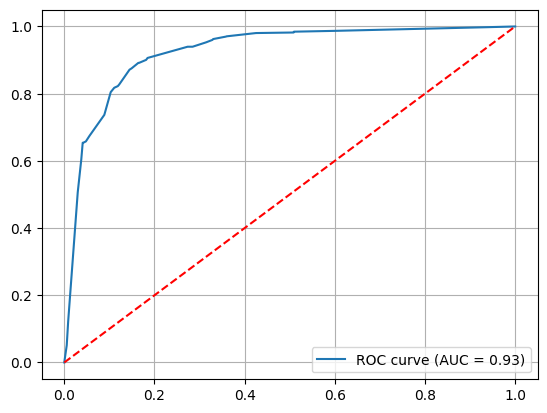

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import seaborn as sns

# Gerar dados
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='Classe 0', marker='o')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='Classe 1', marker='s')
plt.legend()
plt.title('Dados de Treinamento - Moons')
plt.grid()
plt.show()

param_grid = {'max_leaf_nodes': list(range(2, 100))}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor score:", grid.best_score_)

y_pred = grid.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acc:.4f}')

plt.figure(figsize=(20,10))
plot_tree(grid.best_estimator_, filled=True)
plt.show()

mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(mat, annot=True, fmt='d', cmap="Blues")
plt.show()

def plot_decision_boundary(clf, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                          np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm)
    plt.grid()
    plt.show()

plot_decision_boundary(grid.best_estimator_, X_test, y_test)

y_score = grid.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'r--')
plt.legend()
plt.grid()
plt.show()


# Exercício 4 - Random Forest Manual com ShuffleSplit

Acurácia da Random Forest Manual: 0.8660


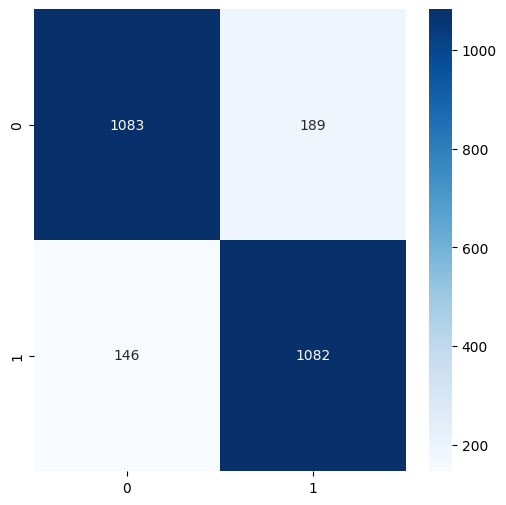

In [ ]:

from sklearn.model_selection import ShuffleSplit
from scipy.stats import mode

ss = ShuffleSplit(n_splits=1000, train_size=100, random_state=42)
trees = []

for train_idx, _ in ss.split(X_train):
    X_sub, y_sub = X_train[train_idx], y_train[train_idx]
    tree = DecisionTreeClassifier(max_leaf_nodes=grid.best_params_['max_leaf_nodes'], random_state=42)
    tree.fit(X_sub, y_sub)
    trees.append(tree)

predictions = np.array([tree.predict(X_test) for tree in trees])
y_pred_rf, _ = mode(predictions, axis=0, keepdims=True)
y_pred_rf = y_pred_rf.flatten()

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Acurácia da Random Forest Manual: {acc_rf:.4f}')

mat = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,6))
sns.heatmap(mat, annot=True, fmt='d', cmap="Blues")
plt.show()
